In [1]:
import sys

assert sys.version_info >= (3, 10), "Python 3.10 or higher is required"

In [2]:
from packaging.version import Version
import sklearn

if Version(sklearn.__version__) < Version("1.6.1"):
    raise RuntimeError("scikit-learn >= 1.6.1 is required")

In [3]:
import pandas as pd

def load_housing_data(path):
    return pd.read_csv(path)

housing_full = load_housing_data(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')

In [4]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### All attributes are numerical, except for ocean_proximity. Its type is object, so it could hold any kind of Python object.

In [6]:
housing_full['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


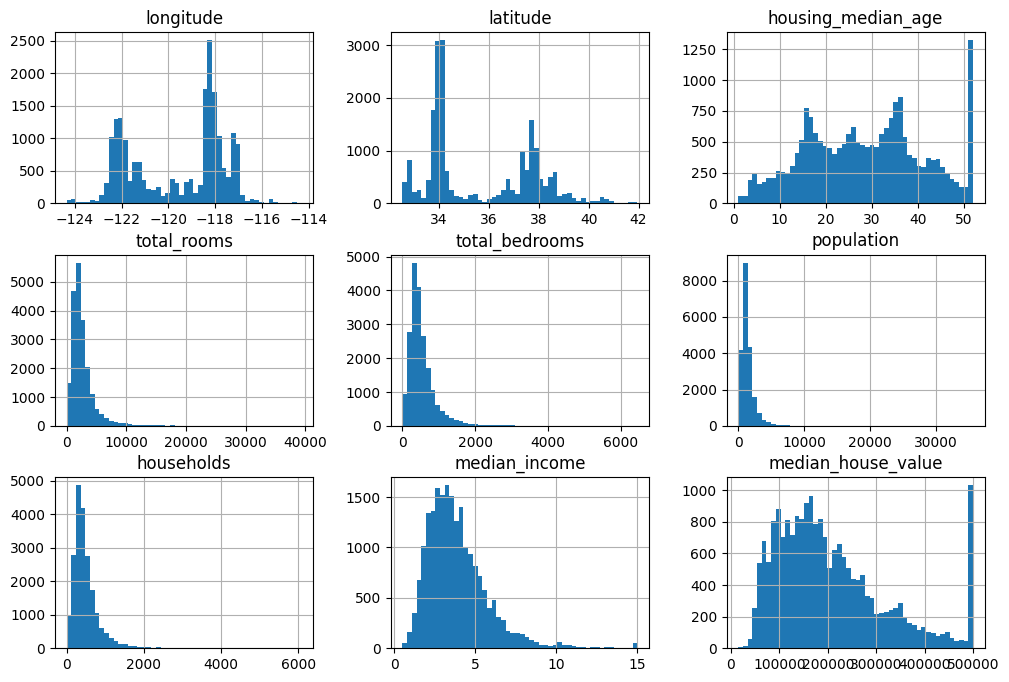

In [8]:
import matplotlib.pyplot as plt

housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

In [9]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [10]:
rng = np.random.default_rng(seed=123)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)

In [11]:
len(train_set), len(test_set)

(16512, 4128)

####  this won't guarantee that this notebook will output exactly the same results !!!!

👉 If you run it again or update your dataset:

* rows can move between train/test 😬
* model evaluation becomes unreliable
✅ What this hash-based method solves

👉 Each row has a stable identity

* Same ID → always same split
* Add new data → old data stays where it was

In [12]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [13]:
housing_with_id = housing_full.reset_index()
housing_with_id.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

#### now let's do same thing with newly created 'id' column

In [15]:
housing_with_id["id"] = (housing_full["longitude"] * 1000
                         + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

#### Or cleanly we can use our build in class Called Data_Splitter_Class which have DataSplitter Class inside of it

In [16]:
import sys
import os

sys.path.append(os.path.abspath(".."))  

from Data_Splitter_Class import DataSplitter

train, test = DataSplitter.split_by_id_hash(housing_with_id, test_ratio=0.2, id_column="id")
train, test = DataSplitter.split_randomly(housing_with_id, test_ratio=0.2)

#### Okay now sklearn has build in class for splitting data which is useful if our data is static and doesnot change over time

In [17]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

### Histogram of income categories

In [18]:
housing_full['income_cat'] = pd.cut(housing_full['median_income'],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

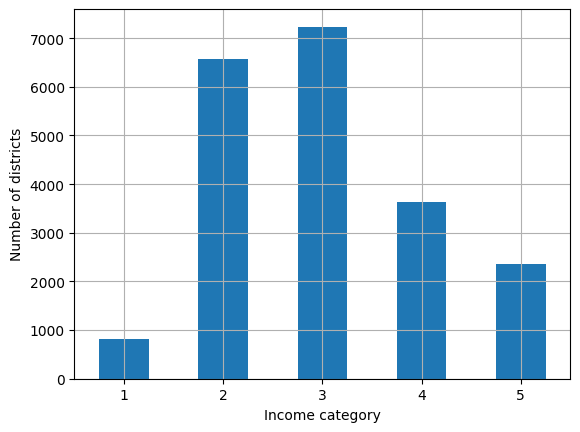

In [19]:
cat_counts = housing_full['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=123)
strat_splits = []

for train_index, test_index in splitter.split(housing_full,
                                              housing_full['income_cat']):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])


In [21]:
strat_train_set, strat_test_set = strat_splits[0]

#### If we have single stratified split then we can simply use train_test_split

In [22]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, stratify=housing_full['income_cat'],
    random_state=123
)

### Discover and Visualize the Data to Gain Insights

In [23]:
housing = strat_train_set.copy()

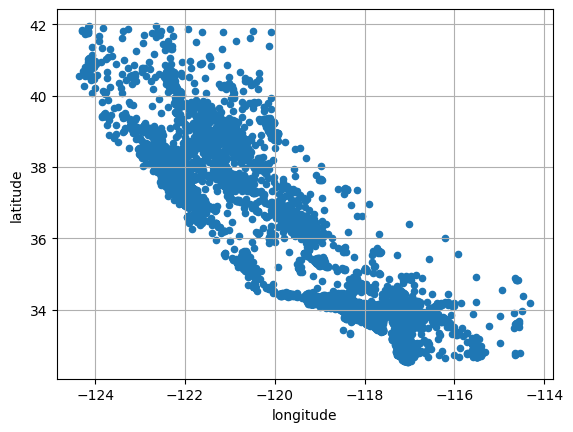

In [24]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True);

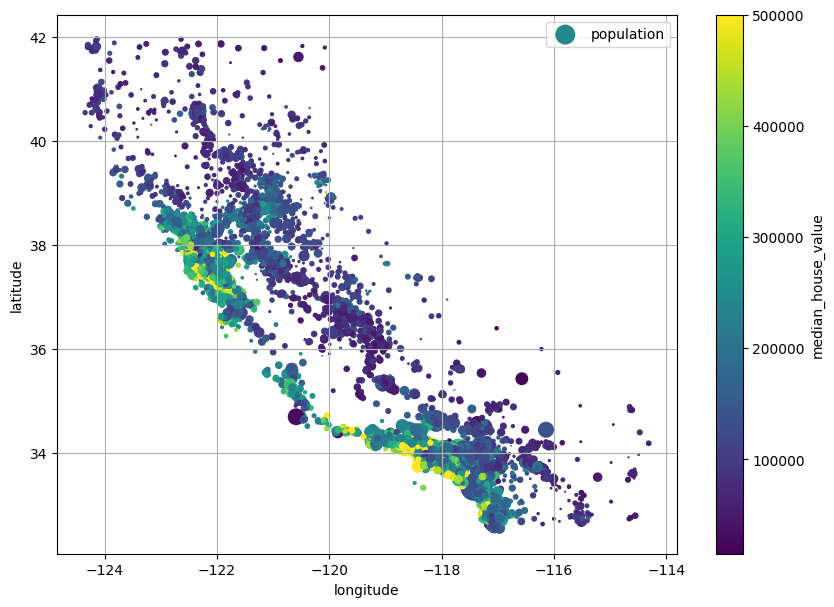

In [25]:
housing.plot(kind='scatter', x="longitude", y="latitude", grid=True,
            s=housing['population'] / 100, label='population',
            c='median_house_value', cmap='viridis', colorbar=True,
            legend=True, sharex=False, figsize=(10, 7));

In [26]:
import plotly.express as px

fig = px.scatter_map(
    housing, 
    lat='latitude',
    lon='longitude',
    color='median_house_value',
    color_continuous_scale='viridis',
    size='population',
    size_max=15, 
    zoom=5,
    opacity=0.6,
    map_style="open-street-map",
    hover_name='ocean_proximity',   
    hover_data={
        'population': True,
        'median_house_value': ':.0f',
        'latitude': False,
        'longitude': False
    }
)

fig.update_layout(
    margin={'l':0,'r':0,'t':0,'b':0},
    width=800,
    title="California Housing Map"
)

### Looking for Correlations

In [27]:
corr = housing.corr(numeric_only=True)

In [28]:
corr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925326,-0.103185,0.039559,0.066232,0.098106,0.051745,-0.020982,-0.049490
latitude,-0.925326,1.000000,0.006627,-0.031671,-0.063725,-0.106952,-0.067375,-0.074747,-0.140864
housing_median_age,-0.103185,0.006627,1.000000,-0.363318,-0.323984,-0.299386,-0.306651,-0.113872,0.107989
total_rooms,0.039559,-0.031671,-0.363318,1.000000,0.930158,0.858381,0.920210,0.198169,0.135419
total_bedrooms,0.066232,-0.063725,-0.323984,0.930158,1.000000,0.877488,0.980226,-0.007059,0.049609
population,0.098106,-0.106952,-0.299386,0.858381,0.877488,1.000000,0.906478,0.006108,-0.024280
households,0.051745,-0.067375,-0.306651,0.920210,0.980226,0.906478,1.000000,0.014504,0.065856
median_income,-0.020982,-0.074747,-0.113872,0.198169,-0.007059,0.006108,0.014504,1.000000,0.691758
median_house_value,-0.049490,-0.140864,0.107989,0.135419,0.049609,-0.024280,0.065856,0.691758,1.000000


In [29]:
pd.DataFrame(corr['median_house_value'].sort_values(ascending=False))

,median_house_value
median_house_value,1.000000
median_income,0.691758
total_rooms,0.135419
housing_median_age,0.107989
households,0.065856
total_bedrooms,0.049609
population,-0.024280
longitude,-0.049490
latitude,-0.140864


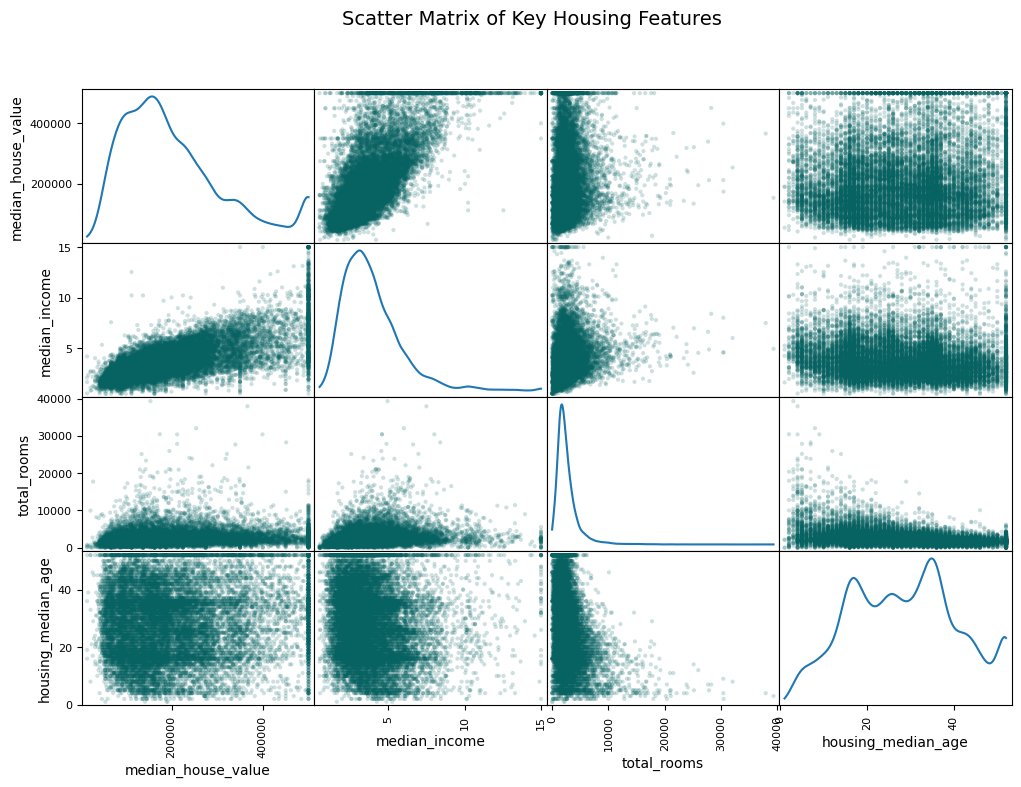

In [30]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "housing_median_age"
]

scatter_matrix(
    housing[attributes],
    figsize=(12, 8),
    alpha=0.2,              
    diagonal='kde',         
    grid=True,
    c="#076262"
)

plt.suptitle("Scatter Matrix of Key Housing Features", fontsize=14)
plt.show()

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2} \cdot \sqrt{\sum (y_i - \bar{y})^2}}
$$

In [31]:
x = housing['median_income']
y = housing['median_house_value']

x_mean = x.mean()
y_mean = y.mean()

In [32]:
x_centered = x - x_mean
y_centered = y - y_mean

numerator = np.sum((x_centered * y_centered))

In [33]:
denominator = np.sqrt(np.sum(x_centered**2)) * np.sqrt(np.sum(y_centered**2))

In [34]:
r = numerator / denominator

In [35]:
print(f'Corr between median_income and median_house_value: {r}')

Corr between median_income and median_house_value: 0.6917580391129176


In [36]:
r_corr = housing[attributes].corr()['median_income']['median_house_value']
r_corr

np.float64(0.6917580391129194)

$$
slope = r \cdot \frac{\sigma_y}{\sigma_x}
$$

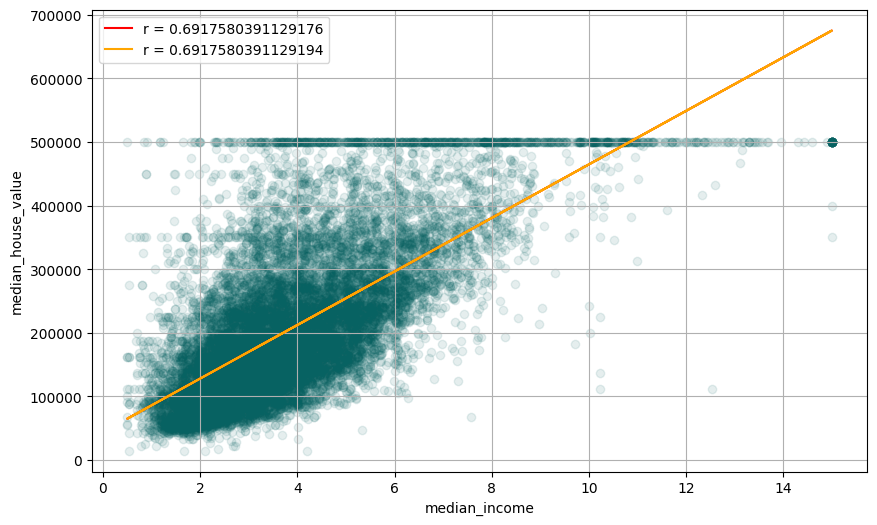

In [37]:
x_std = x.std()
y_std = y.std()

slope1 = r * (y_std / x_std)
slope2 = r_corr * (y_std / x_std) 

b1 = y_mean - slope1 * x_mean
b2 = y_mean - slope2 * x_mean

def line(x, slope, intercept):
    return slope * x + intercept

plt.figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.1, color="#076262")

plt.plot(x, line(x, slope1, b1), color="red", label=f"r = {r}")
plt.plot(x, line(x, slope2, b2), color="orange", label=f"r = {r_corr}")

plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
fig2 = px.imshow(
    corr,
    color_continuous_scale='RdBu',
    text_auto=".2f",
    aspect='auto'
)

fig2.update_layout(margin={'t':10, 'b':15}, width=800)

In [39]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [40]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.691758
rooms_per_house       0.151388
total_rooms           0.135419
housing_median_age    0.107989
households            0.065856
total_bedrooms        0.049609
people_per_house     -0.020659
population           -0.024280
longitude            -0.049490
latitude             -0.140864
bedrooms_ratio       -0.261397
Name: median_house_value, dtype: float64

### Prepare the Data for Machine Learning Algorithms

In [41]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

### Data Cleaning

In [42]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 20027 to 14441
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16343 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB


In [43]:
median = housing['total_bedrooms'].median()
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median)

In [44]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 20027 to 14441
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16512 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB


In [45]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat


In [46]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

In [47]:
housing_num = housing.select_dtypes(include='number')
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20027,-122.04,37.59,14.0,1727.0,302.0,1116.0,273.0,5.3428
1979,-118.31,34.03,29.0,2438.0,867.0,2114.0,753.0,0.8351
17230,-122.41,37.78,52.0,1014.0,422.0,1055.0,382.0,1.8519
10479,-121.99,37.98,23.0,2293.0,411.0,969.0,399.0,4.4536
17537,-117.21,34.49,14.0,2125.0,348.0,1067.0,360.0,3.6333
...,...,...,...,...,...,...,...,...
19139,-117.36,34.11,35.0,2969.0,521.0,1555.0,503.0,3.2500
2439,-124.17,40.78,39.0,1606.0,330.0,731.0,327.0,1.6369
7331,-117.37,33.22,35.0,2204.0,482.0,1435.0,462.0,3.6760
10662,-118.28,34.00,48.0,1514.0,376.0,1353.0,344.0,2.1607


In [48]:
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [49]:
imputer.statistics_  # same as computed the median of each attribute

array([-118.48  ,   34.25  ,   29.    , 2125.5   ,  435.    , 1168.    ,
        410.    ,    3.5313])

In [50]:
X = imputer.transform(housing_num)

In [51]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [52]:
X

array([[-1.2204e+02,  3.7590e+01,  1.4000e+01, ...,  1.1160e+03,
         2.7300e+02,  5.3428e+00],
       [-1.1831e+02,  3.4030e+01,  2.9000e+01, ...,  2.1140e+03,
         7.5300e+02,  8.3510e-01],
       [-1.2241e+02,  3.7780e+01,  5.2000e+01, ...,  1.0550e+03,
         3.8200e+02,  1.8519e+00],
       ...,
       [-1.1737e+02,  3.3220e+01,  3.5000e+01, ...,  1.4350e+03,
         4.6200e+02,  3.6760e+00],
       [-1.1828e+02,  3.4000e+01,  4.8000e+01, ...,  1.3530e+03,
         3.4400e+02,  2.1607e+00],
       [-1.1762e+02,  3.3420e+01,  2.7000e+01, ...,  4.6000e+02,
         2.4300e+02,  3.1029e+00]], shape=(16512, 8))

In [53]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [54]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20027,-122.04,37.59,14.0,1727.0,302.0,1116.0,273.0,5.3428
1979,-118.31,34.03,29.0,2438.0,867.0,2114.0,753.0,0.8351
17230,-122.41,37.78,52.0,1014.0,422.0,1055.0,382.0,1.8519
10479,-121.99,37.98,23.0,2293.0,411.0,969.0,399.0,4.4536
17537,-117.21,34.49,14.0,2125.0,348.0,1067.0,360.0,3.6333
...,...,...,...,...,...,...,...,...
19139,-117.36,34.11,35.0,2969.0,521.0,1555.0,503.0,3.2500
2439,-124.17,40.78,39.0,1606.0,330.0,731.0,327.0,1.6369
7331,-117.37,33.22,35.0,2204.0,482.0,1435.0,462.0,3.6760
10662,-118.28,34.00,48.0,1514.0,376.0,1353.0,344.0,2.1607


In [55]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income


#### Let's drop some outliers

In [56]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=123)
outlier_pred = isolation_forest.fit_predict(X)

In [57]:
outlier_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(16512,))

In [58]:
housing['outlier'] = outlier_pred

In [59]:
housing = housing[outlier_pred == 1]
housing_labels = housing_labels[outlier_pred == 1]

In [60]:
housing_cat = housing[['ocean_proximity']]
housing_cat.head()

,ocean_proximity
20027,NEAR BAY
1979,<1H OCEAN
17230,NEAR BAY
10479,INLAND
17537,INLAND


In [61]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [62]:
housing_cat_encoded[:5]

array([[3.],
       [0.],
       [3.],
       [1.],
       [1.]])

In [63]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [64]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [65]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14356 stored elements and shape (14356, 5)>

In [66]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(14356, 5))

In [67]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(14356, 5))

In [68]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [69]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [70]:
df_output = pd.DataFrame(cat_encoder.transform(df_test),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test.index)

In [71]:
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0


### Feature Scaling

In [72]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [73]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

We log-transform because we want to:

1. Reduce skewness
* Big values shrink more than small ones
* Makes distribution more balanced
2. Stabilize variance
* Helps models (especially linear models)
* Prevents large values from dominating
3. Make relationships more linear

Example:

* Without log → curved relationship
* With log → more straight-line relationship

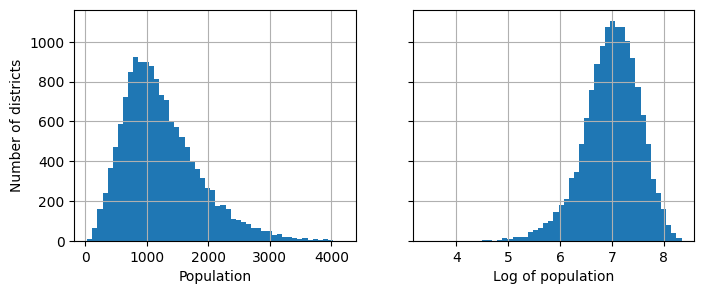

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

### Gaussian RBF feature measuring the similarity between the housing median age and 35

In [75]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

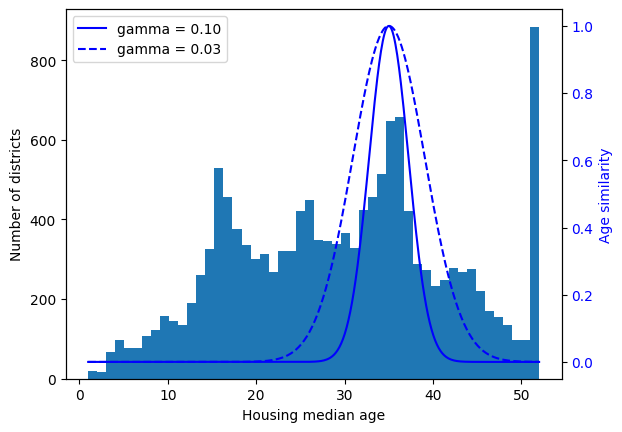

In [76]:
ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx() 
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")

plt.show()

In [77]:
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
scaled_labels = scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  

scaled_predictions = model.predict(some_new_data)
predictions = scaler.inverse_transform(scaled_predictions)

In [78]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [79]:
predictions

array([276034.34255574,  70608.4649139 , 116946.29404765, 235511.52817166,
       198128.63946354])

### Custom Transformers

In [80]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [81]:
ratio_transformer = FunctionTransformer(lambda X:X[:,0] / X[:, 1])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([0.5 , 0.75])

In [82]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean
    
    def fit(self, X, y=None):
        X = check_array(X)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]
        return self
    
    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [83]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, y, sample_weight=sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
    
    def fit_transform(self, X, y = None, **fit_params):
        return super().fit_transform(X, y, **fit_params)

In [84]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=123)
similarities = cluster_simil.fit_transform(housing[['latitude', 'longitude']])

In [85]:
similarities.round(2)

array([[0.  , 0.91, 0.  , ..., 0.82, 0.19, 0.  ],
       [0.05, 0.  , 0.06, ..., 0.  , 0.  , 0.68],
       [0.  , 0.97, 0.  , ..., 0.52, 0.42, 0.  ],
       ...,
       [0.78, 0.  , 0.  , ..., 0.  , 0.  , 0.56],
       [0.06, 0.  , 0.05, ..., 0.  , 0.  , 0.71],
       [0.51, 0.  , 0.  , ..., 0.  , 0.  , 0.78]], shape=(14356, 10))

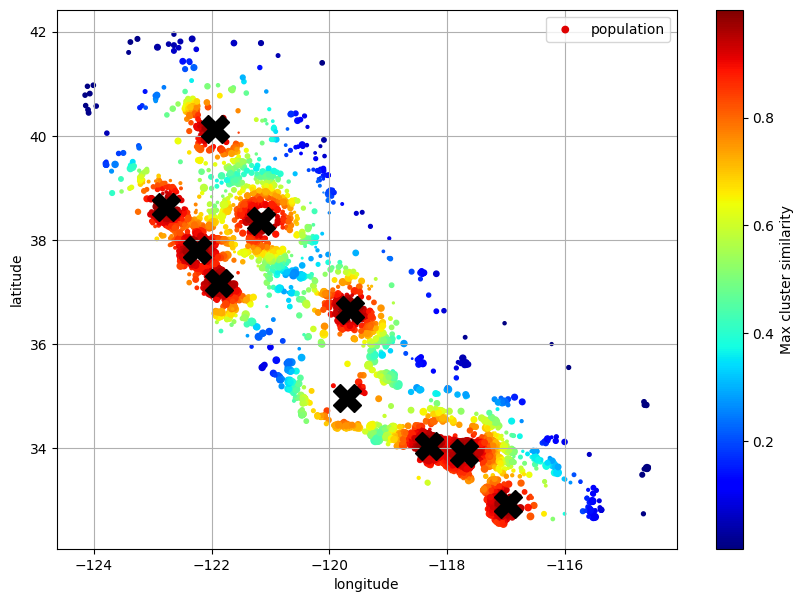

In [86]:
housing["Max cluster similarity"] = similarities.max(axis=1)
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
                     s=housing["population"] / 100, label="population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))

plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

### Transformation Pipelines

In [87]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### If you don’t want to have to name the transformers, you can use the convenient make_pipeline() function instead

In [88]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

In [89]:
from sklearn import set_config

set_config(display='diagram')
num_pipeline

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [90]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared.round(2)

array([[-1.23,  0.92, -1.16, ..., -0.28, -0.59,  0.77],
       [ 0.62, -0.75,  0.03, ...,  0.61,  0.66, -1.59],
       [-1.42,  1.  ,  1.86, ..., -0.33, -0.31, -1.06],
       ...,
       [ 1.09, -1.13,  0.51, ...,  0.01, -0.1 , -0.1 ],
       [ 0.64, -0.76,  1.54, ..., -0.07, -0.41, -0.9 ],
       [ 0.97, -1.03, -0.13, ..., -0.86, -0.67, -0.4 ]], shape=(16512, 8))

In [91]:
housing_num_prepared = pd.DataFrame(housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
                                    index=housing_num.index)

In [92]:
housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20027,-1.231721,0.915940,-1.163833,-0.416417,-0.561129,-0.276173,-0.594072,0.772553
1979,0.624922,-0.747637,0.029486,-0.091358,0.790654,0.606234,0.663301,-1.594964
17230,-1.415892,1.004726,1.859241,-0.742391,-0.274025,-0.330108,-0.308543,-1.060924
10479,-1.206833,1.098185,-0.447841,-0.157650,-0.300343,-0.406147,-0.264011,0.305531
17537,1.172458,-0.532681,-1.163833,-0.234457,-0.451072,-0.319498,-0.366173,-0.125304
...,...,...,...,...,...,...,...,...
19139,1.097794,-0.710254,0.506814,0.151408,-0.037163,0.111980,0.008420,-0.326619
2439,-2.291949,2.406617,0.825032,-0.471737,-0.494138,-0.616581,-0.452617,-1.173846
7331,1.092816,-1.126148,0.506814,-0.198339,-0.130472,0.005878,-0.098981,-0.102877
10662,0.639855,-0.761656,1.541023,-0.513798,-0.384081,-0.066624,-0.408085,-0.898738


In [93]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

##### So far, we have handled the categorical columns and the numerical columns separately. It would be more convenient to have a single transformer capable of handling all columns, applying the appropriate transformations to each column. For this, you can use a ColumnTransformer.

In [94]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

In [95]:
housing_prepared = preprocessing.fit_transform(housing)

In [96]:
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index
)
housing_prepared_fr

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
20027,-1.291748,0.975714,-1.307335,-0.460984,-0.709407,-0.193515,-0.769567,0.952388,0.0,0.0,0.0,1.0,0.0
1979,0.627958,-0.741238,-0.056823,0.203689,1.855675,1.433035,1.579264,-1.767267,1.0,0.0,0.0,0.0,0.0
17230,-1.482175,1.067349,1.860629,-1.127526,-0.164611,-0.292933,-0.236186,-1.153795,0.0,0.0,0.0,1.0,0.0
10479,-1.266015,1.163807,-0.557028,0.068137,-0.214550,-0.433097,-0.152999,0.415902,0.0,1.0,0.0,0.0,0.0
17537,1.194091,-0.519384,-1.307335,-0.088917,-0.500568,-0.273376,-0.343841,-0.079014,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6500,-0.061695,0.377675,0.693484,0.867427,0.498224,0.233495,0.522290,-0.534230,0.0,1.0,0.0,0.0,0.0
19139,1.116891,-0.702654,0.443382,0.700090,0.284846,0.521971,0.355914,-0.310272,0.0,1.0,0.0,0.0,0.0
7331,1.111744,-1.131892,0.443382,-0.015064,0.107787,0.326394,0.155285,-0.053252,0.0,0.0,0.0,0.0,1.0
10662,0.643398,-0.755706,1.527159,-0.660105,-0.373449,0.192750,-0.422136,-0.967485,1.0,0.0,0.0,0.0,0.0


#### Since listing all the column names is not very convenient, Scikit-Learn provides a make_column_selector class that you can use to automatically select all the features of a given type, such as numerical or categorical.

In [97]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

### Your project is going really well and you’re almost ready to train some models! You now want to create a single pipeline that will perform all the transformations you’ve experimented with up to now. Let’s recap what the pipeline will do and why:
* Missing values in numerical features will be imputed by replacing them with the median, as most ML algorithms don’t expect missing values. In categorical features, missing values will be replaced by the most frequent category.
* The categorical feature will be one-hot encoded, as most ML algorithms only accept numerical inputs.
* A few ratio features will be computed and added: bedrooms_ratio, rooms_per_house, and people_per_house. Hopefully these will better correlate with the median house value, and thereby help the ML models.
* A few cluster similarity features will also be added. These will likely be more useful to the model than latitude and longitude.
* Features with a long tail will be replaced by their logarithm, as most models prefer features with roughly uniform or Gaussian distributions.
* All numerical features will be standardized, as most ML algorithms prefer when all features have roughly the same scale.

In [98]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, feature_names_out='one-to-one'),
    StandardScaler()
)
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

preprocessing = ColumnTransformer([
    ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ("rooms_per_house", ratio_pipeline(), ['total_rooms', 'households']),
    ('people_per_house', ratio_pipeline(), ['population', 'households']),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline
)

In [99]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(14356, 27)

In [100]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__income_cat',
       'remainder__outlier', 'remainder__Max cluster similarity'],
      dtype=object)

### Select and Train a Model

In [101]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)

array([241000., 104700., 185800., 216100., 140700.])

In [103]:
housing_labels.iloc[:5].values

array([243600., 150000.,  32500., 184000., 116200.])

In [104]:
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f'{100 * ratio:.1f}%' for ratio in error_ratios]))

-1.1%, -30.2%, 471.7%, 17.4%, 21.1%


In [105]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

64428.96682361928

In [106]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

### Better Evaluation Using Cross-Validation

Instead of splitting once, it splits **multiple times** and averages the results.

**K-Fold Cross-Validation (e.g., k=5):**
```
Full Data: [■■■■■■■■■■■■■■■■■■■■]

Fold 1:  [TEST|train|train|train|train]  → score 1
Fold 2:  [train|TEST|train|train|train]  → score 2
Fold 3:  [train|train|TEST|train|train]  → score 3
Fold 4:  [train|train|train|TEST|train]  → score 4
Fold 5:  [train|train|train|train|TEST]  → score 5

Final Score = mean(score1, score2, score3, score4, score5)

In [108]:
from sklearn.model_selection import cross_val_score

tree_rmses = cross_val_score(tree_reg, housing, housing_labels, 
                             scoring='neg_root_mean_squared_error', cv=10)

In [109]:
pd.Series(tree_rmses).describe()

count       10.000000
mean    -64606.278519
std       2426.289353
min     -67728.078362
25%     -66684.163929
50%     -64574.603995
75%     -62364.227504
max     -61889.341457
dtype: float64

#### So far we dicovered that Linear_Regression is underfitting the problem whereas Decision_Tree is overfitting the problem

### Now let's try Random_Forest_Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=123)
                           )

forest_rmses = cross_val_score(forest_reg, housing, housing_labels,
                               scoring='neg_root_mean_squared_error', cv=10)